***Imports & Configuration ***

In [1]:
# === Imports ===
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# === Configuration générale ===
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


***Unzipping the ZIP file***

In [2]:
import zipfile
import os

zip_path = r"C:\Users\TECHMATE DZ\Downloads\archive.zip"
output_dir = r"C:\Users\TECHMATE DZ\Documents\eye-diseases-classification"

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(zip_path):
    print(f"❌ ERREUR : Le fichier n'existe pas : {zip_path}")
else:
    print("📦 Extraction en cours...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)
    print("✅ Extraction terminée !")

    print("📂 Contenu du dossier extrait :")
    print(os.listdir(output_dir))


📦 Extraction en cours...
✅ Extraction terminée !
📂 Contenu du dossier extrait :
['dataset']


***Prepare Train/Val/Test***

In [3]:
base_dir = r"C:\Users\TECHMATE DZ\Documents\eye-diseases-classification\dataset"
output_dir = r"C:\Users\TECHMATE DZ\Documents\dataset_split"

# Vérification du dossier source
if not os.path.exists(base_dir):
    print(f"❌ ERREUR : Dossier introuvable : {base_dir}")
else:
    print(f"📁 Dossier dataset trouvé : {base_dir}")

    classes = [
        d for d in os.listdir(base_dir)
        if os.path.isdir(os.path.join(base_dir, d))
    ]

    print("📝 Classes détectées :", classes)

    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    # Split 70% / 15% / 15%
    for cls in classes:
        cls_path = os.path.join(base_dir, cls)
        imgs = os.listdir(cls_path)
        random.shuffle(imgs)

        n = len(imgs)
        train_end = int(0.7 * n)
        val_end = int(0.85 * n)

        print(f"\n📊 Classe : {cls} ({n} images)")
        print(f" - Train : {train_end}")
        print(f" - Val   : {val_end - train_end}")
        print(f" - Test  : {n - val_end}")

        for i, img in enumerate(imgs):
            src = os.path.join(cls_path, img)

            if i < train_end:
                dst = os.path.join(output_dir, "train", cls, img)
            elif i < val_end:
                dst = os.path.join(output_dir, "val", cls, img)
            else:
                dst = os.path.join(output_dir, "test", cls, img)

            shutil.copy(src, dst)

    print("\n✅ Dataset bien séparé !")


📁 Dossier dataset trouvé : C:\Users\TECHMATE DZ\Documents\eye-diseases-classification\dataset
📝 Classes détectées : ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

📊 Classe : cataract (1038 images)
 - Train : 726
 - Val   : 156
 - Test  : 156

📊 Classe : diabetic_retinopathy (1098 images)
 - Train : 768
 - Val   : 165
 - Test  : 165

📊 Classe : glaucoma (1007 images)
 - Train : 704
 - Val   : 151
 - Test  : 152

📊 Classe : normal (1074 images)
 - Train : 751
 - Val   : 161
 - Test  : 162

✅ Dataset bien séparé !


***Data Generators with augmentation***

In [4]:
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,      # ⚠ tu avais mis test_dir ici → corrigé
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 2949 images belonging to 4 classes.
Found 633 images belonging to 4 classes.


***CNN from scratch***

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, LeakyReLU

num_classes = len(train_generator.class_indices)

model = Sequential([

    # Block 1
    Conv2D(32, (3,3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4),
           input_shape=(224,224,3)),
    BatchNormalization(),
    LeakyReLU(),
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(),
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(),
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(2,2),

    # Block 4 — ajouté, très important
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(2,2),

    # Classification head
    Flatten(),
    Dense(256),
    LeakyReLU(),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 224, 224, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 224, 224, 32)      0

***CNN training***

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6)
]
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)


Epoch 1/50
93/93 [==============================] - 104s 1s/step - loss: 2.6930 - accuracy: 0.4452 - val_loss: 2.2136 - val_accuracy: 0.2464 - lr: 1.0000e-04
Epoch 2/50
93/93 [==============================] - 31s 327ms/step - loss: 1.8502 - accuracy: 0.5307 - val_loss: 2.2556 - val_accuracy: 0.3017 - lr: 1.0000e-04
Epoch 3/50
93/93 [==============================] - 31s 328ms/step - loss: 1.6891 - accuracy: 0.5480 - val_loss: 2.3212 - val_accuracy: 0.3017 - lr: 1.0000e-04
Epoch 4/50
93/93 [==============================] - 31s 333ms/step - loss: 1.4325 - accuracy: 0.5826 - val_loss: 1.7389 - val_accuracy: 0.4471 - lr: 1.0000e-04
Epoch 5/50
93/93 [==============================] - 37s 400ms/step - loss: 1.3069 - accuracy: 0.6094 - val_loss: 1.4178 - val_accuracy: 0.4787 - lr: 1.0000e-04
Epoch 6/50
93/93 [==============================] - 46s 491ms/step - loss: 1.2729 - accuracy: 0.6087 - val_loss: 1.5913 - val_accuracy: 0.5719 - lr: 1.0000e-04
Epoch 7/50
93/93 [========================

***EfficientNetB0 Fine-tuning (Phase 1 + Phase 2)***

In [7]:
IMG_SIZE = (224, 224)
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")

NUM_CLASSES = len(classes)

train_gen = ImageDataGenerator(preprocess_input).flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_gen = ImageDataGenerator(preprocess_input).flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)


Found 2949 images belonging to 4 classes.
Found 633 images belonging to 4 classes.


***Phase 1 — Frozen base***

In [8]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_ft = Model(inputs, outputs)

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_ft.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/10


c:\Users\TECHMATE DZ\anaconda3\envs\tf\lib\site-packages\keras\preprocessing\image.py:1863: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


93/93 [==============================] - 18s 155ms/step - loss: 1.3198 - accuracy: 0.3788 - val_loss: 1.0939 - val_accuracy: 0.5972
Epoch 2/10
93/93 [==============================] - 13s 143ms/step - loss: 1.0819 - accuracy: 0.5331 - val_loss: 0.9188 - val_accuracy: 0.7030
Epoch 3/10
93/93 [==============================] - 13s 143ms/step - loss: 0.9281 - accuracy: 0.6178 - val_loss: 0.8150 - val_accuracy: 0.7551
Epoch 4/10
93/93 [==============================] - 13s 140ms/step - loss: 0.8491 - accuracy: 0.6663 - val_loss: 0.7461 - val_accuracy: 0.7662
Epoch 5/10
93/93 [==============================] - 13s 143ms/step - loss: 0.7904 - accuracy: 0.7009 - val_loss: 0.6973 - val_accuracy: 0.7694
Epoch 6/10
93/93 [==============================] - 13s 144ms/step - loss: 0.7443 - accuracy: 0.7189 - val_loss: 0.6622 - val_accuracy: 0.7788
Epoch 7/10
93/93 [==============================] - 14s 146ms/step - loss: 0.7136 - accuracy: 0.7270 - val_loss: 0.6316 - val_accuracy: 0.7883
Epoch 8/10

***Phase 2 — Partial unblocking of layers***

In [9]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft2 = model_ft.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/20
93/93 [==============================] - 20s 169ms/step - loss: 0.5445 - accuracy: 0.7938 - val_loss: 0.4273 - val_accuracy: 0.8483
Epoch 2/20
93/93 [==============================] - 14s 155ms/step - loss: 0.4127 - accuracy: 0.8562 - val_loss: 0.3247 - val_accuracy: 0.8910
Epoch 3/20
93/93 [==============================] - 14s 152ms/step - loss: 0.3434 - accuracy: 0.8834 - val_loss: 0.2749 - val_accuracy: 0.9036
Epoch 4/20
93/93 [==============================] - 14s 151ms/step - loss: 0.2924 - accuracy: 0.8966 - val_loss: 0.2485 - val_accuracy: 0.9194
Epoch 5/20
93/93 [==============================] - 14s 153ms/step - loss: 0.2557 - accuracy: 0.9108 - val_loss: 0.2365 - val_accuracy: 0.9179
Epoch 6/20
93/93 [==============================] - 14s 154ms/step - loss: 0.2500 - accuracy: 0.9081 - val_loss: 0.2240 - val_accuracy: 0.9179
Epoch 7/20
93/93 [==============================] - 14s 151ms/step - loss: 0.2264 - accuracy: 0.9162 - val_loss: 0.2172 - val_accuracy: 0.9273

***Confusion matrix + Report***

Found 635 images belonging to 4 classes.
20/20 [==============================] - 18s 944ms/step


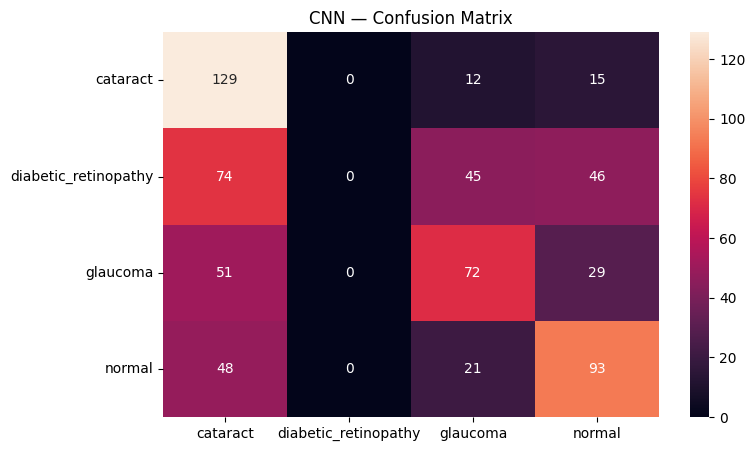

CNN Classification Report :
                      precision    recall  f1-score   support

            cataract       0.43      0.83      0.56       156
diabetic_retinopathy       0.00      0.00      0.00       165
            glaucoma       0.48      0.47      0.48       152
              normal       0.51      0.57      0.54       162

            accuracy                           0.46       635
           macro avg       0.35      0.47      0.39       635
        weighted avg       0.35      0.46      0.39       635



c:\Users\TECHMATE DZ\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\TECHMATE DZ\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\TECHMATE DZ\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

20/20 [==============================] - 3s 132ms/step


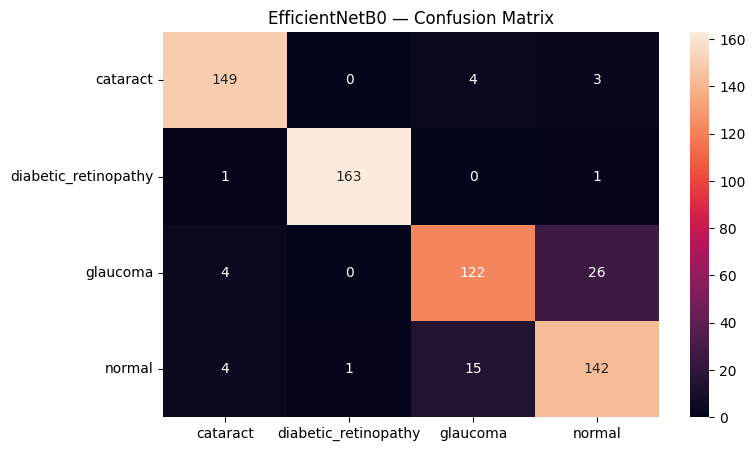

EfficientNetB0 Classification Report :
                      precision    recall  f1-score   support

            cataract       0.94      0.96      0.95       156
diabetic_retinopathy       0.99      0.99      0.99       165
            glaucoma       0.87      0.80      0.83       152
              normal       0.83      0.88      0.85       162

            accuracy                           0.91       635
           macro avg       0.91      0.91      0.91       635
        weighted avg       0.91      0.91      0.91       635



In [10]:
test_gen = ImageDataGenerator(preprocess_input).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

y_true = test_gen.classes

# --- CNN ---
y_pred_cnn = np.argmax(model.predict(test_gen), axis=1)

cm_cnn = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(8,5))
sns.heatmap(cm_cnn, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("CNN — Confusion Matrix")
plt.show()

print("CNN Classification Report :")
print(classification_report(y_true, y_pred_cnn, target_names=classes))


# --- EfficientNetB0 ---
y_pred_ft = np.argmax(model_ft.predict(test_gen), axis=1)

cm_ft = confusion_matrix(y_true, y_pred_ft)

plt.figure(figsize=(8,5))
sns.heatmap(cm_ft, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("EfficientNetB0 — Confusion Matrix")
plt.show()

print("EfficientNetB0 Classification Report :")
print(classification_report(y_true, y_pred_ft, target_names=classes))


***Predection***

Found 635 images belonging to 4 classes.
1/1 [==============================] - 0s 460ms/step


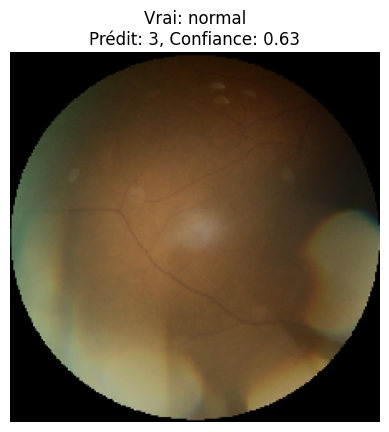

1/1 [==============================] - 0s 24ms/step


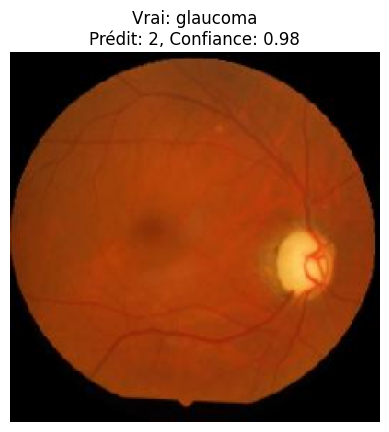

1/1 [==============================] - 0s 19ms/step


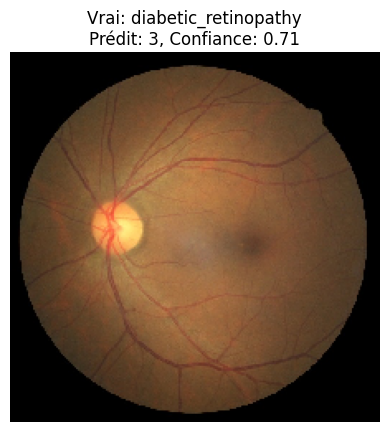

1/1 [==============================] - 0s 18ms/step


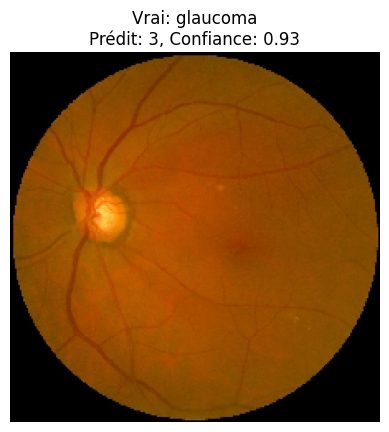

1/1 [==============================] - 0s 26ms/step


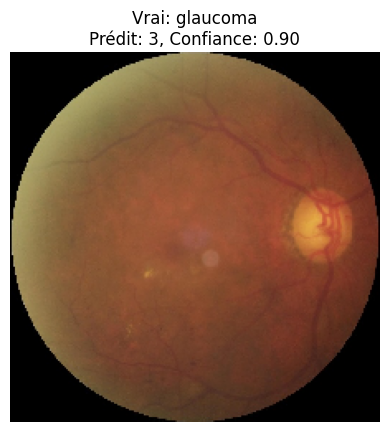

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1️⃣ Créer le générateur pour le test
test_dir = r"C:\Users\TECHMATE DZ\Documents\dataset_split\test"
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',  # pour prédiction multi-classes
    shuffle=True
)

# 2️⃣ Sélectionner aléatoirement 5 images
num_images = min(5, test_generator.samples)

for i in range(num_images):
    img, label = test_generator.next()
    pred = model.predict(img)
    class_index = np.argmax(pred)
    confidence = np.max(pred)
    
    plt.imshow(img[0])
    # Obtenir le nom du sous-dossier (classe vraie) et prédiction
    true_class = list(test_generator.class_indices.keys())[np.argmax(label)]
    plt.title(f"Vrai: {true_class}\nPrédit: {class_index}, Confiance: {confidence:.2f}")
    plt.axis('off')
    plt.show()
